In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split   # для разбиения данных на обучающую и тестовую выборки
from sklearn.preprocessing import StandardScaler       # для стандартизации признаков
from sklearn.linear_model import LinearRegression       # линейная модель регрессии
from sklearn.tree import DecisionTreeRegressor          # дерево решений для регрессии
from sklearn.neighbors import KNeighborsRegressor # к-ближайших значений
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # метрики оценки качества модели

In [45]:
# Загрузка файла, удаление нечисловых переменных и проверка пропущенных значений
df = pd.read_csv("/content/sample_data/Life Expectancy Data.csv")

df = df.drop(columns=["Country", "Status"], errors="ignore")

df = df.select_dtypes(include=["number"])

print("Количество пропущенных значений в каждом столбце:\n", df.isnull().sum())

Количество пропущенных значений в каждом столбце:
 Year                                 0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
 BMI                                34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
 HIV/AIDS                            0
GDP                                448
Population                         652
 thinness  1-19 years               34
 thinness 5-9 years                 34
Income composition of resources    167
Schooling                          163
dtype: int64


In [37]:
# Описание числовых данных
print("\nСтатистика по числовым данным:")
df.describe()


Статистика по числовым данным:


,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [38]:
# Заполняем пропуски медианой
for column in df.columns:
    if column in df.columns:
        df[column] = df[column].fillna(np.median(df[column].dropna()))
        print(f"Пропущенные значения в столбце '{column}' были заполнены медианой.")
    else:
        print(f"Столбец '{column}' не найден в данных!")

Пропущенные значения в столбце 'Year' были заполнены медианой.
Пропущенные значения в столбце 'Life expectancy ' были заполнены медианой.
Пропущенные значения в столбце 'Adult Mortality' были заполнены медианой.
Пропущенные значения в столбце 'infant deaths' были заполнены медианой.
Пропущенные значения в столбце 'Alcohol' были заполнены медианой.
Пропущенные значения в столбце 'percentage expenditure' были заполнены медианой.
Пропущенные значения в столбце 'Hepatitis B' были заполнены медианой.
Пропущенные значения в столбце 'Measles ' были заполнены медианой.
Пропущенные значения в столбце ' BMI ' были заполнены медианой.
Пропущенные значения в столбце 'under-five deaths ' были заполнены медианой.
Пропущенные значения в столбце 'Polio' были заполнены медианой.
Пропущенные значения в столбце 'Total expenditure' были заполнены медианой.
Пропущенные значения в столбце 'Diphtheria ' были заполнены медианой.
Пропущенные значения в столбце ' HIV/AIDS' были заполнены медианой.
Пропущенные з

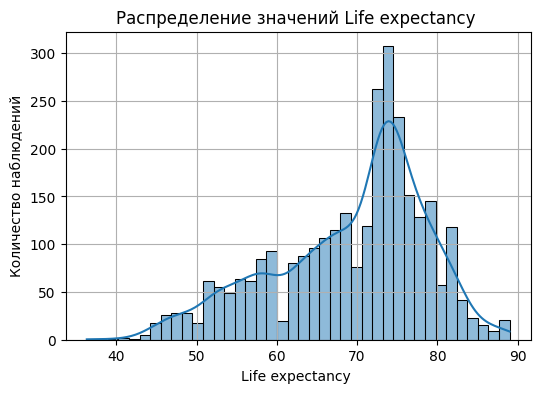

In [39]:
# Строим гистограмму для оценки распределения значений переменной Life expectancy
target = "Life expectancy "

plt.figure(figsize=(6, 4))
sns.histplot(df[target], bins=40, kde=True)
plt.title("Распределение значений Life expectancy ")
plt.xlabel("Life expectancy ")
plt.ylabel("Количество наблюдений")
plt.grid(True)
plt.show()

In [40]:
# Делим данные на признаки (X) и целевую переменную (y)
X = df.drop(columns=[target])
y = df[target]

# Масштабируем признаки, чтобы все переменные имели одинаковый масштаб
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разделяем данные на обучающую и тестовую выборки: 80% для обучения, 20% для оценки
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [41]:
# Объявляем модели для задачи регрессии
models = {
    "Линейная регрессия": LinearRegression(),
    "Дерево решений": DecisionTreeRegressor(max_depth=6),
    "К-ближайших соседей": KNeighborsRegressor()
}

# Сохраняем метрики в список
results = []

# Обучаем каждую модель, делаем предсказание и рассчитываем метрики
for name, model in models.items():
    model.fit(X_train, y_train)  # обучение модели на тренировочных данных
    y_pred = model.predict(X_test)  # предсказания на тестовой выборке

    mae = mean_absolute_error(y_test, y_pred)  # средняя абсолютная ошибка
    mse = mean_squared_error(y_test, y_pred)  # среднеквадратичная ошибка
    r2 = r2_score(y_test, y_pred)  # коэффициент детерминации R2

    results.append({"Модель": name, "MAE": mae, "MSE": mse, "R2": r2})

    print(f"\n{name}")
    print("Средняя абсолютная ошибка (MAE):", round(mae, 3))
    print("Среднеквадратичная ошибка (MSE):", round(mse, 3))
    print("Коэффициент детерминации (R2):", round(r2, 3))


Линейная регрессия
Средняя абсолютная ошибка (MAE): 2.857
Среднеквадратичная ошибка (MSE): 15.402
Коэффициент детерминации (R2): 0.822

Дерево решений
Средняя абсолютная ошибка (MAE): 1.89
Среднеквадратичная ошибка (MSE): 6.912
Коэффициент детерминации (R2): 0.92

К-ближайших соседей
Средняя абсолютная ошибка (MAE): 1.847
Среднеквадратичная ошибка (MSE): 6.851
Коэффициент детерминации (R2): 0.921


In [42]:
# Преобразуем результаты в таблицу
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)
print("Сравнительная таблица метрик моделей:")
display(results_df)

Сравнительная таблица метрик моделей:


,Модель,MAE,MSE,R2
2,К-ближайших соседей,1.847415,6.850574,0.920956
1,Дерево решений,1.889543,6.912197,0.920245
0,Линейная регрессия,2.857389,15.402131,0.822285


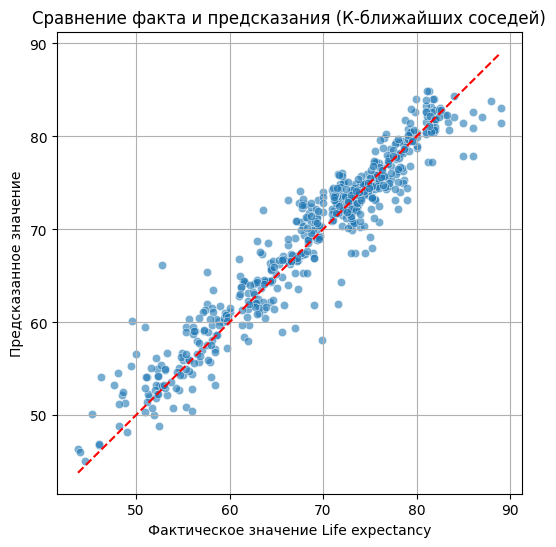

In [47]:
# Получаем модель с наибольшим R2
best_model_name = results_df.iloc[0]["Модель"]
best_model = models[best_model_name]

# Предсказания на тестовой выборке
y_pred_best = best_model.predict(X_test)

# Строим график
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_test, y=y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel("Фактическое значение Life expectancy")
plt.ylabel("Предсказанное значение")
plt.title(f"Сравнение факта и предсказания ({best_model_name})")
plt.grid(True)
plt.show()

In [ ]:
Общий результат:
На графике точки в основном лежат близко к диагональной линии (y = x), что указывает на высокую точность предсказаний модели.
Точечное облако хорошо симметрично относительно диагонали, что говорит об отсутствии значительных систематических ошибок модели.

Точность модели:
Средняя абсолютная ошибка (MAE), равная 1.847, свидетельствует, что в среднем предсказания модели отклоняются от реальных значений на 1.85 года.
Среднеквадратичная ошибка (MSE) равна 6.85, что дополнительно подтверждает стабильность модели, хотя большие отклонения наказываются сильнее.
Коэффициент детерминации R² = 0.92 говорит, что модель объясняет 92% вариации данных, что демонстрирует сильные предсказательные способности.

In [ ]:
Первоначально была проведена очистка данных: удалены нерелевантные столбцы с текстовой информацией, оставлены только числовые признаки,
а также проверена целостность данных путем выявления и обработки пропусков. Для улучшения процесса обучения моделей, числовые признаки были масштабированы.
Подготовленный набор данных был разделен на обучающую и тестовую выборки для оценки эффективности моделей.

В качестве алгоритмов прогнозирования были использованы три модели: линейная регрессия, дерево решений и метод К-ближайших соседей.
Сравнение моделей проводилось на основе метрик качества: MAE (средняя абсолютная ошибка), MSE (среднеквадратичная ошибка) и R² (коэффициент детерминации).
Анализ показал, что модель К-ближайших соседей обеспечивает наиболее точные прогнозы целевой переменной.

Для визуальной оценки качества предсказаний был построен график сравнения фактических и предсказанных значений.
Преобладающее расположение точек вдоль диагонали подтверждает высокую точность полученных результатов.

В заключение, цель проекта была успешно достигнута. Данные были тщательно подготовлены, обучены и протестированы несколько моделей, и на основе анализа метрик
была обоснованно выбрана наиболее эффективная модель для прогнозирования дневной стоимости телефонных разговоров.